# Phase 1 — Data Loading & Exploratory Data Analysis (EDA)

**Goal:** Understand the raw data *before* cleaning it.

This dataset is **men's clothing** (polo shirts, t-shirts, jeans, chinos, dress pants).
We have two files:

- `products.csv` — one row per product (title, description, price, rating, category, etc.)
- `reviews.csv` — many rows per product (review text + a pre-computed sentiment score)

In this notebook we only **look** at the data. We do NOT clean or change it yet.
Cleaning happens in Phase 2.

## 1. Imports & load the data

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

data_dir = '../Amazon-Ecom_dataset'

products = pd.read_csv(f'{data_dir}/products.csv')
reviews = pd.read_csv(f'{data_dir}/reviews.csv')

print('products shape:', products.shape)
print('reviews  shape:', reviews.shape)

products shape: (728, 34)
reviews  shape: (6327, 23)


## 2. What columns do we have?

Real-world data has many columns we will not use. Let's list them all first.

In [30]:
print('--- PRODUCTS columns ---')
print(list(products.columns))
print()
print('--- REVIEWS columns ---')
print(list(reviews.columns))

--- PRODUCTS columns ---
['s.no', 'about_item', 'asin', 'availability', 'best_sellers_rank', 'brand_name', 'brand_page_url', 'breadcrumbs', 'customer_review_summary', 'default_variant/0', 'default_variant/1', 'default_variant/2', 'delivery_date', 'fastest_delivery_date', 'list_price', 'manufacturer', 'model_number', 'price_value', 'product_description', 'product_url', 'rating_count', 'rating_distribution/1star', 'rating_distribution/2star', 'rating_distribution/3star', 'rating_distribution/4star', 'rating_distribution/5star', 'rating_stars', 'recent_purchases', 'scrape_time', 'seller_name', 'seller_page_url', 'title', 'all_images', 'rank_1']

--- REVIEWS columns ---
['s.no', 'helpfulVoteCount', 'images/0', 'images/1', 'images/2', 'images/3', 'images/4', 'images/5', 'images/6', 'images/7', 'productASIN', 'productVariant', 'rating', 'reviewID', 'reviewMetadata', 'reviewPosition', 'reviewText', 'reviewTitle', 'reviewURL', 'verifiedPurchase', 'videos/0', 'cleaned_review_text', 'sentiment_s

In [31]:
# Peek at a few products (only the columns we care about for search/ranking)
cols_we_care = [
    'asin', 'title', 'brand_name', 'breadcrumbs', 'price_value',
    'rating_stars', 'rating_count', 'best_sellers_rank', 'availability'
]
products[cols_we_care].head(5)

,asin,title,brand_name,breadcrumbs,price_value,rating_stars,rating_count,best_sellers_rank,availability
0,B0B59BJG6Y,4/5 Pack Mens Polo Shirts Short Sleeve Quick D...,MLYENX Store,"Clothing, Shoes & Jewelry › Men › Clothing › A...",39.9926,4.6 out of 5 stars,"1,654 ratings","#56,836 in Clothing, Shoes & Jewelry (See Top ...",In Stock
1,B0DLGB4RYH,COOFANDY Men's Polo Shirts Short Sleeve Moistu...,COOFANDY Store,"Clothing, Shoes & Jewelry › Men › Clothing › S...",19.9920,4.4 out of 5 stars,20 ratings,"#50,261 in Clothing, Shoes & Jewelry (See Top ...",In Stock
2,B0DRXF62JH,ZITY 3 Pack Men Polo Shirts Short Sleeve with ...,ZITY Store,"Clothing, Shoes & Jewelry › Men › Clothing › A...",29.9950,4.6 out of 5 stars,5 ratings,"#69,641 in Clothing, Shoes & Jewelry (See Top ...",In Stock
3,B0DK5FZ325,Rouen Mens Golf Shirt Moisture Wicking Dry Fit...,Rouen Store,"Clothing, Shoes & Jewelry › Men › Clothing › A...",32.9500,4.8 out of 5 stars,22 ratings,"#194,649 in Clothing, Shoes & Jewelry (See Top...",In Stock
4,B0BGXTC1FR,V VALANCH Mens Polo Shirts Short Sleeve Moistu...,V VALANCH Store,"Clothing, Shoes & Jewelry › Men › Clothing › A...",26.9931,4.4 out of 5 stars,"2,175 ratings","#3,664 in Clothing, Shoes & Jewelry (See Top 1...",In Stock


## 3. The columns are messy — let's see HOW messy

Notice these are **text**, not numbers, even though they hold numbers:

- `rating_stars` looks like `"4.4 out of 5 stars"`
- `rating_count` looks like `"20 ratings"`
- `best_sellers_rank` looks like `"#85 in Men's Activewear Polos"`
- `breadcrumbs` is a long category path like `"Clothing... > Polos"`

We will fix these in Phase 2. For now we just confirm the format.

In [32]:
for col in ['rating_stars', 'rating_count', 'best_sellers_rank', 'breadcrumbs', 'price_value']:
    print(f'--- {col} ---')
    print(products[col].dropna().head(3).tolist())
    print('dtype:', products[col].dtype)
    print()

--- rating_stars ---
['4.6 out of 5 stars', '4.4 out of 5 stars', '4.6 out of 5 stars']
dtype: str

--- rating_count ---
['1,654 ratings', '20 ratings', '5 ratings']
dtype: str

--- best_sellers_rank ---
["#56,836 in Clothing, Shoes & Jewelry (See Top 100 in Clothing, Shoes & Jewelry)    #85 in Men's Activewear Polos", "#50,261 in Clothing, Shoes & Jewelry (See Top 100 in Clothing, Shoes & Jewelry)    #199 in Men's Polo Shirts", "#69,641 in Clothing, Shoes & Jewelry (See Top 100 in Clothing, Shoes & Jewelry)    #111 in Men's Activewear Polos"]
dtype: str

--- breadcrumbs ---
['Clothing, Shoes & Jewelry › Men › Clothing › Active › Active Shirts & Tees › Polos', 'Clothing, Shoes & Jewelry › Men › Clothing › Shirts › Polos', 'Clothing, Shoes & Jewelry › Men › Clothing › Active › Active Shirts & Tees › Polos']
dtype: str

--- price_value ---
[39.9926, 19.992, 29.995]
dtype: float64



## 4. Missing values (nulls)

Before we build features we must know which columns have gaps.

In [33]:
null_pct = (products.isna().mean() * 100).round(1).sort_values(ascending=False)
null_pct_we_care = null_pct[[
    'title', 'about_item', 'product_description', 'price_value',
    'rating_stars', 'rating_count', 'best_sellers_rank', 'breadcrumbs', 'brand_name'
]]
print('Missing % for the columns we plan to use:')
print(null_pct_we_care)

Missing % for the columns we plan to use:
title                   0.0
about_item              0.0
product_description    62.8
price_value             2.9
rating_stars            1.2
rating_count            1.2
best_sellers_rank      23.4
breadcrumbs             1.8
brand_name              0.0
dtype: float64


## 5. How many unique products? Any duplicates?

`asin` is the product ID. It should be unique.

In [34]:
print('Total rows      :', len(products))
print('Unique asin     :', products['asin'].nunique())
print('Duplicate asin  :', products['asin'].duplicated().sum())

Total rows      : 728
Unique asin     : 728
Duplicate asin  : 0


## 6. What categories of clothing are in here?

The last part of `breadcrumbs` (after the final `>`) is the real category,
e.g. `Polos`, `T-Shirts`, `Jeans`. Let's pull it out just for exploring.

In [35]:
def last_breadcrumb(text):
    if pd.isna(text):
        return 'Unknown'
    # breadcrumbs use the ' › ' arrow as separator
    parts = str(text).replace('>', '›').split('›')
    return parts[-1].strip()

category_preview = products['breadcrumbs'].apply(last_breadcrumb)
print('Top categories:')
print(category_preview.value_counts().head(15))

Top categories:
breadcrumbs
Jeans                           72
Polos                           60
T-Shirts                        59
Casual                          50
Blouses & Button-Down Shirts    34
Active Shorts                   28
Boxer Briefs                    28
Fashion Sneakers                24
Road Running                    22
Sweatpants                      17
Tunics                          16
Dress                           15
Unknown                         13
Undershirts                     12
Button-Down Shirts              12
Name: count, dtype: int64


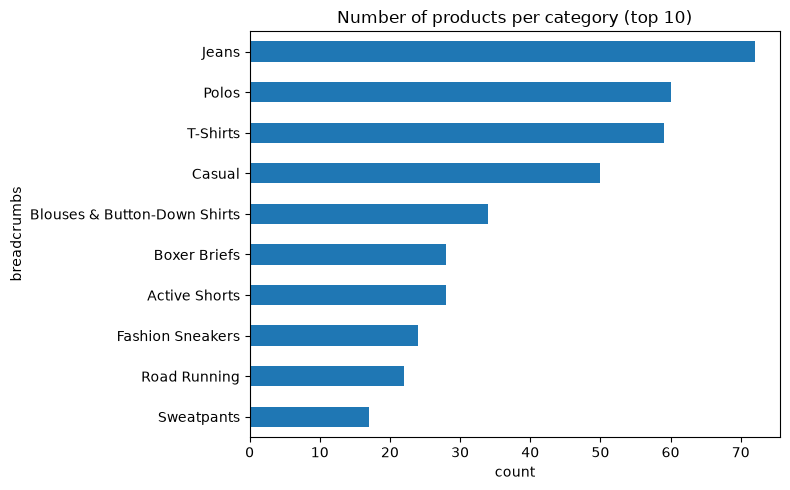

In [36]:
category_preview.value_counts().head(10).sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Number of products per category (top 10)')
plt.xlabel('count')
plt.tight_layout()
plt.show()

## 7. Price and rating — quick numeric look

`price_value` is already numeric. For `rating_stars` we grab just the leading
number so we can see the distribution (full parsing comes in Phase 2).

In [37]:
# leading number from 'rating_stars' just for this preview
rating_preview = products['rating_stars'].astype(str).str.extract(r'([0-9.]+)')[0].astype(float)

print('PRICE summary:')
print(products['price_value'].describe().round(2))
print()
print('RATING summary:')
print(rating_preview.describe().round(2))

PRICE summary:
count    707.00
mean      35.32
std       26.42
min        5.46
25%       19.99
50%       28.95
75%       41.77
max      249.99
Name: price_value, dtype: float64

RATING summary:
count    719.00
mean       4.38
std        0.33
min        1.00
25%        4.30
50%        4.40
75%        4.60
max        5.00
Name: 0, dtype: float64


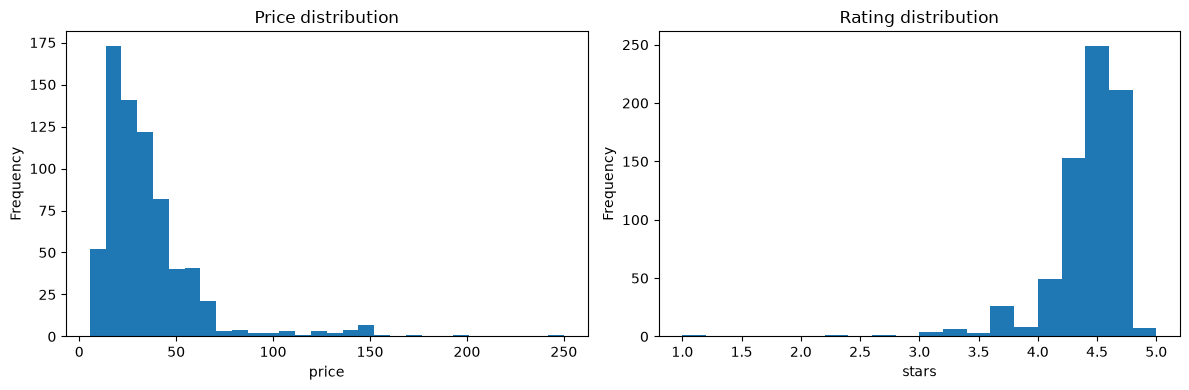

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
products['price_value'].dropna().plot(kind='hist', bins=30, ax=ax[0])
ax[0].set_title('Price distribution')
ax[0].set_xlabel('price')
rating_preview.dropna().plot(kind='hist', bins=20, ax=ax[1])
ax[1].set_title('Rating distribution')
ax[1].set_xlabel('stars')
plt.tight_layout()
plt.show()

## 8. Reviews file — the join key and the free sentiment

`reviews.productASIN` matches `products.asin`. Good news: the reviews file
already has a `sentiment_score` and a `cleaned_review_text`, so we don't have
to compute sentiment ourselves later.

In [39]:
review_cols = ['productASIN', 'rating', 'reviewText', 'cleaned_review_text',
               'sentiment_score', 'helpfulVoteCount', 'verifiedPurchase']
reviews[review_cols].head(5)

,productASIN,rating,reviewText,cleaned_review_text,sentiment_score,helpfulVoteCount,verifiedPurchase
0,B0DLGB4RYH,5.0,‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fant...,coofandy men polo shirt fantastic blend style ...,0.292024,0,False
1,B0DRXF62JH,5.0,I love these. They look good. They fit well. T...,love look good fit well comfortable breathable...,0.560000,0,False
2,B0DRXF62JH,4.0,My expectations were low -- how good could shi...,expectation low good could shirt sell one mist...,0.192321,0,False
3,B0DRXF62JH,5.0,This 3-pack of multi-color shirts is really a ...,pack multicolor shirt really brainer wear type...,0.307949,0,False
4,B0DRXF62JH,5.0,With these three polo shirts I was very satisf...,three polo shirt satisfied quality material go...,0.250000,0,False


In [40]:
print('Total reviews              :', len(reviews))
print('Products that have reviews :', reviews['productASIN'].nunique())
print('Products with NO reviews   :', products['asin'].nunique() - reviews['productASIN'].nunique())
print()
print('sentiment_score summary:')
print(reviews['sentiment_score'].describe().round(3))

Total reviews              : 6327
Products that have reviews : 700
Products with NO reviews   : 28

sentiment_score summary:
count    6327.000
mean        0.308
std         0.218
min        -1.000
25%         0.169
50%         0.300
75%         0.450
max         1.000
Name: sentiment_score, dtype: float64


Reviews per product summary:
count    700.0
mean       9.0
std        2.7
min        1.0
25%       10.0
50%       10.0
75%       10.0
max       19.0
dtype: float64


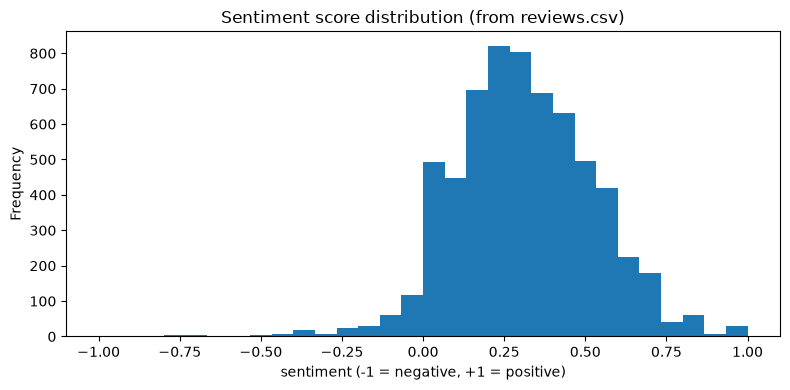

In [41]:
# How many reviews does each product have? (this becomes a feature later)
reviews_per_product = reviews.groupby('productASIN').size()
print('Reviews per product summary:')
print(reviews_per_product.describe().round(1))

reviews['sentiment_score'].dropna().plot(kind='hist', bins=30, figsize=(8, 4))
plt.title('Sentiment score distribution (from reviews.csv)')
plt.xlabel('sentiment (-1 = negative, +1 = positive)')
plt.tight_layout()
plt.show()

## 9. Summary — what we learned (actual results)

**Size**
- `products.csv` = **728 products**, 34 columns. `asin` is unique (no duplicates).
- `reviews.csv` = **6,327 reviews**, joins to products via `productASIN` = `asin`.

**Domain (categories)**
- Men's **apparel + footwear**: top categories are Jeans (72), Polos (60), T-Shirts (59),
  Casual shirts (50), Button-Down Shirts (34), plus Shorts, Boxer Briefs, Sneakers, Running shoes.
- So demo queries should be clothing/shoe style, e.g. *"best budget polo shirt for golf"*,
  *"slim fit jeans for work"*, *"breathable running shoes"*.

**Numbers**
- Price: median ≈ **$28.95**, ranges ~$5 to $250.
- Rating: median ≈ **4.4 stars** (most products are 4.0–4.8 — ratings alone won't separate items well,
  so similarity + price + sentiment matter more).

**Columns that hide numbers inside text → must parse in Phase 2**
- `rating_stars` → `"4.4 out of 5 stars"` → 4.4
- `rating_count` → `"1,654 ratings"` → 1654
- `best_sellers_rank` → `"... #85 in Men's Activewear Polos"` → 85 (+ sub-category)
- `breadcrumbs` → last node = category
- `price_value` is already numeric.

**Missing data to handle in Phase 2**
- `product_description` is **62.8% empty** → build `search_text` mainly from `title` + `about_item`
  (use description only when present).
- `best_sellers_rank` ~23% empty, `price` ~3% empty, `rating` ~1% empty → need fallbacks.
- **28 products have no reviews** → sentiment / review-count features need a default value.

**Free win**
- `reviews.csv` already has `sentiment_score` (mean ≈ +0.31, mostly positive) and
  `cleaned_review_text` → we reuse these instead of computing sentiment ourselves.

**Next: Phase 2 — clean and merge everything into a single `data/cleaned_products.csv`.**
